# Full Precision 3B vs Mellum4B

Confronto tabelle + plot per gli stessi esperimenti, limitato a:
- `full_precision 3b`
- `mellum4b`

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

line_cycler = (
    cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"])
    + cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."])
)
plt.rc("axes", prop_cycle=line_cycler)

METRICS = ["em", "bleu", "meteor", "rougeL"]
EPS = ["ep0", "ep1", "ep2", "ep3"]
PLENS = ["p100", "p150", "p200", "p250"]
DEDUPS = ["d1", "d2", "d3", "dg3"]

FP3B_COLOR = "#E69F00"
ME4B_COLOR = "#56B4E9"

def add_bar_labels(ax, bars, pad_frac=0.03, min_pad=0.001, ha="center", x_shift_frac=0.0):
    heights = np.array([bar.get_height() for bar in bars], dtype=float)
    if heights.size == 0:
        return 0.0, 0.0
    max_abs = max(np.max(np.abs(heights)), 1e-6)
    pad = max(min_pad, max_abs * pad_frac)
    low, high = [], []
    for bar, h in zip(bars, heights):
        y = h + pad if h >= 0 else h - pad
        va = "bottom" if h >= 0 else "top"
        x = bar.get_x() + bar.get_width() / 2.0 + bar.get_width() * x_shift_frac
        ax.text(
            x,
            y,
            f"{h:.3f}",
            ha=ha,
            va=va,
            fontsize=8,
            clip_on=False,
        )
        low.append(min(h, y))
        high.append(max(h, y))
    return float(np.min(low)), float(np.max(high))

def add_dual_bar_labels(
    ax,
    bars_left,
    bars_right,
    pad_frac=0.03,
    min_pad=0.001,
    overlap_frac=0.06,
    side_shift_frac=0.14,
):
    h_left = np.array([bar.get_height() for bar in bars_left], dtype=float)
    h_right = np.array([bar.get_height() for bar in bars_right], dtype=float)
    if h_left.size == 0 or h_right.size == 0:
        return 0.0, 0.0
    all_h = np.concatenate([h_left, h_right])
    max_abs = max(np.max(np.abs(all_h)), 1e-6)
    pad = max(min_pad, max_abs * pad_frac)
    overlap_thr = max_abs * overlap_frac + pad
    low, high = [], []
    for bar_l, h_l, bar_r, h_r in zip(bars_left, h_left, bars_right, h_right):
        is_overlap = abs(h_l - h_r) <= overlap_thr
        if is_overlap:
            configs = [
                (bar_l, h_l, "right", -side_shift_frac),
                (bar_r, h_r, "left", side_shift_frac),
            ]
        else:
            configs = [
                (bar_l, h_l, "center", 0.0),
                (bar_r, h_r, "center", 0.0),
            ]
        for bar, h, ha, shift in configs:
            y = h + pad if h >= 0 else h - pad
            va = "bottom" if h >= 0 else "top"
            x = bar.get_x() + bar.get_width() / 2.0 + bar.get_width() * shift
            ax.text(x, y, f"{h:.3f}", ha=ha, va=va, fontsize=8, clip_on=False)
            low.append(min(h, y))
            high.append(max(h, y))
    return float(np.min(low)), float(np.max(high))

def set_smart_ylim(ax, values, label_bounds=None, include_zero=True, margin_frac=0.08):
    vals = np.array(values, dtype=float).reshape(-1)
    if label_bounds is not None:
        vals = np.concatenate([vals, np.array(label_bounds, dtype=float).reshape(-1)])
    if vals.size == 0:
        return
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    if include_zero:
        vmin = min(vmin, 0.0)
        vmax = max(vmax, 0.0)
    span = max(vmax - vmin, 1e-6)
    ax.set_ylim(vmin - span * margin_frac, vmax + span * margin_frac)

def mean_from_roots(df, roots, labels):
    data = {
        metric: [df[f"{root}_{metric}"].mean() for root in roots]
        for metric in METRICS
    }
    return pd.DataFrame(data, index=labels)

def plot_2model_bar(df_compare, x_label, title, out_pdf):
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    x = np.arange(len(df_compare.index))
    width = 0.35

    bars_fp = ax.bar(x - width / 2, df_compare["fp3b"], width, label="full_precision_3b", color=FP3B_COLOR)
    bars_me = ax.bar(x + width / 2, df_compare["mellum4b"], width, label="mellum4b", color=ME4B_COLOR)

    lb_pair, ub_pair = add_dual_bar_labels(ax, bars_fp, bars_me)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel(x_label)
    ax.set_ylabel("EM (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare.index)
    ax.set_title(title, pad=18)

    all_vals = np.concatenate([df_compare["fp3b"].values, df_compare["mellum4b"].values])
    set_smart_ylim(ax, all_vals, label_bounds=(lb_pair, ub_pair))

    ax.legend(frameon=True, loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight")


# Attack-mem-ep

In [35]:
fp_path = "../full_precision/memorization/experiments/attack_mem_ep/attack_mem_ep.parquet"
me_path = "./memorization/attack_mem_ep/attack_mem_ep.parquet"

df_fp = pd.read_parquet(fp_path)
df_me = pd.read_parquet(me_path)

fp_abs = mean_from_roots(df_fp, [f"3b_{ep}" for ep in EPS], EPS)
me_abs = mean_from_roots(df_me, [f"me4b_{ep}" for ep in EPS], EPS)

fp_base = fp_abs.subtract(fp_abs.iloc[0])
me_base = me_abs.subtract(me_abs.iloc[0])

mem_ep_compare = pd.DataFrame(
    {
        "fp3b": fp_base["em"],
        "mellum4b": me_base["em"],
    },
    index=EPS,
)
mem_ep_compare


,fp3b,mellum4b
ep0,0.000,0.000
ep1,0.196,0.011
ep2,0.332,0.035
ep3,0.368,0.050


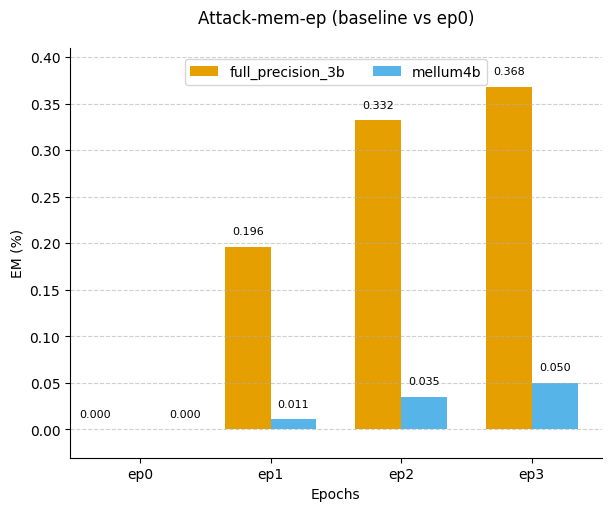

In [36]:
plot_2model_bar(
    mem_ep_compare,
    x_label="Epochs",
    title="Attack-mem-ep (baseline vs ep0)",
    out_pdf="./bar-compare_mem_ep_fp3b_vs_mellum4b.pdf",
)


# Attack-mem-dedup

In [37]:
fp_base_dir = "../full_precision/memorization/experiments/attack_mem_dedup"
me_base_dir = "./memorization/attack_mem_dedup"

fp_dfs = [
    pd.read_parquet(os.path.join(fp_base_dir, "attack_mem_dedup_1.parquet")),
    pd.read_parquet(os.path.join(fp_base_dir, "attack_mem_dedup_2.parquet")),
    pd.read_parquet(os.path.join(fp_base_dir, "attack_mem_dedup_3.parquet")),
    pd.read_parquet(os.path.join(fp_base_dir, "attack_mem_dedup_g3.parquet")),
]
me_dfs = [
    pd.read_parquet(os.path.join(me_base_dir, "attack_mem_dedup_1.parquet")),
    pd.read_parquet(os.path.join(me_base_dir, "attack_mem_dedup_2.parquet")),
    pd.read_parquet(os.path.join(me_base_dir, "attack_mem_dedup_3.parquet")),
    pd.read_parquet(os.path.join(me_base_dir, "attack_mem_dedup_g3.parquet")),
]

fp_ep3_em = [fp_dfs[i][f"3b_ep3_{DEDUPS[i]}_em"].mean() for i in range(len(DEDUPS))]
fp_ep0_em = [fp_dfs[i][f"3b_ep0_{DEDUPS[i]}_em"].mean() for i in range(len(DEDUPS))]
me_ep3_em = [me_dfs[i][f"me4b_ep3_{DEDUPS[i]}_em"].mean() for i in range(len(DEDUPS))]
me_ep0_em = [me_dfs[i][f"me4b_ep0_{DEDUPS[i]}_em"].mean() for i in range(len(DEDUPS))]

mem_dedup_compare = pd.DataFrame(
    {
        "fp3b": np.array(fp_ep3_em) - np.array(fp_ep0_em),
        "mellum4b": np.array(me_ep3_em) - np.array(me_ep0_em),
    },
    index=DEDUPS,
)
mem_dedup_compare


,fp3b,mellum4b
d1,0.025,0.005
d2,0.172,0.026
d3,0.329,0.064
dg3,0.368,0.046


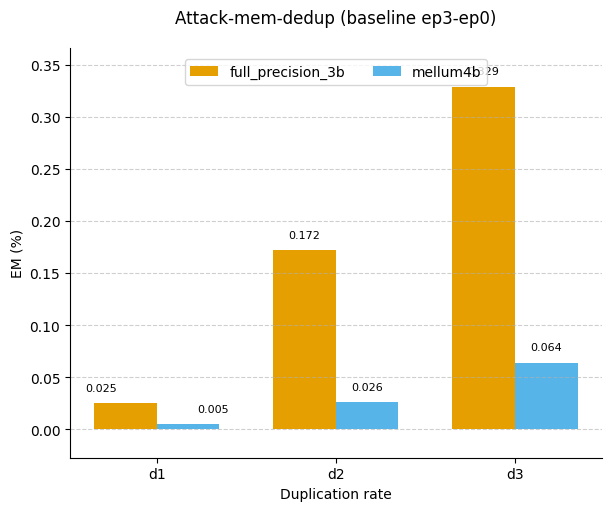

In [38]:
mem_dedup_plot = mem_dedup_compare.loc[["d1", "d2", "d3"]]
plot_2model_bar(
    mem_dedup_plot,
    x_label="Duplication rate",
    title="Attack-mem-dedup (baseline ep3-ep0)",
    out_pdf="./bar-compare_mem_dedup_fp3b_vs_mellum4b.pdf",
)


# Attack-mem-plen

In [39]:
fp_path = "../full_precision/memorization/experiments/attack_mem_plen/attack_mem_plen.parquet"
me_path = "./memorization/attack_mem_plen/attack_mem_plen.parquet"

df_fp = pd.read_parquet(fp_path)
df_me = pd.read_parquet(me_path)

fp_ep3 = np.array([df_fp[f"3b_ep3_{p}_em"].mean() for p in PLENS])
fp_ep0 = np.array([df_fp[f"3b_ep0_{p}_em"].mean() for p in PLENS])
me_ep3 = np.array([df_me[f"me4b_ep3_{p}_em"].mean() for p in PLENS])
me_ep0 = np.array([df_me[f"me4b_ep0_{p}_em"].mean() for p in PLENS])

mem_plen_compare = pd.DataFrame(
    {
        "fp3b": fp_ep3 - fp_ep0,
        "mellum4b": me_ep3 - me_ep0,
    },
    index=PLENS,
)
mem_plen_compare


,fp3b,mellum4b
p100,0.367,0.050
p150,0.393,0.081
p200,0.443,0.101
p250,0.502,0.095


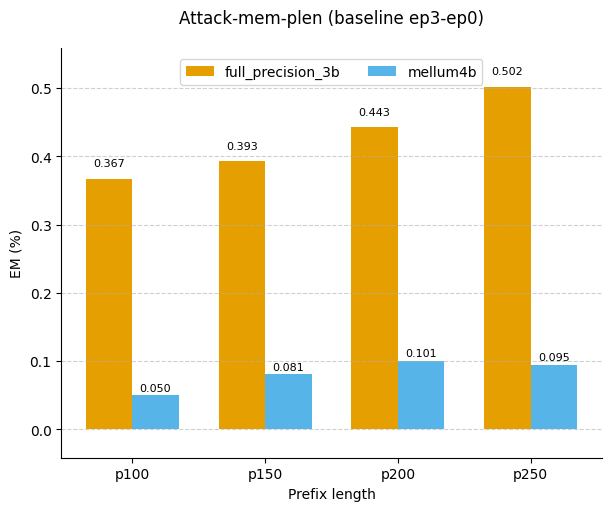

In [29]:
plot_2model_bar(
    mem_plen_compare,
    x_label="Prefix length",
    title="Attack-mem-plen (baseline ep3-ep0)",
    out_pdf="./bar-compare_mem_plen_fp3b_vs_mellum4b.pdf",
)


# Attack-forg-ep

In [30]:
fp_path = "../full_precision/forgeting/experiments/attack_forg_ep/attack_forg_ep.parquet"
me_path = "./forgetting/attack_forg_ep/attack_forg_ep.parquet"

df_fp = pd.read_parquet(fp_path)
df_me = pd.read_parquet(me_path)

forg_ep_compare = pd.DataFrame(
    {
        "fp3b": [df_fp[f"3b_{ep}_em"].mean() for ep in EPS],
        "mellum4b": [df_me[f"me4b_{ep}_em"].mean() for ep in EPS],
    },
    index=EPS,
)
forg_ep_compare


,fp3b,mellum4b
ep0,0.389,0.010
ep1,0.087,0.001
ep2,0.108,0.002
ep3,0.105,0.003


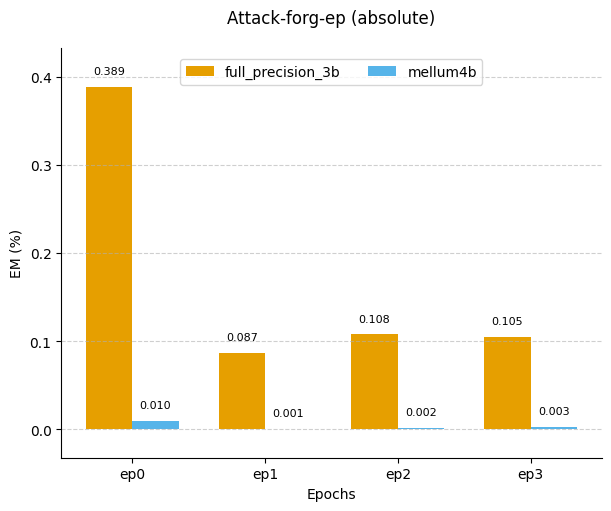

In [40]:
plot_2model_bar(
    forg_ep_compare,
    x_label="Epochs",
    title="Attack-forg-ep (absolute)",
    out_pdf="./bar-compare_forg_ep_fp3b_vs_mellum4b.pdf",
)


# Attack-forg-plen

In [41]:
fp_path = "../full_precision/forgeting/experiments/attack_forg_plen/attack_forg_plen.parquet"
me_path = "./forgetting/attack_forg_plen/attack_forg_plen.parquet"

df_fp = pd.read_parquet(fp_path)
df_me = pd.read_parquet(me_path)

fp_ep0 = np.array([df_fp[f"3b_ep0_{p}_em"].mean() for p in PLENS])
fp_ep3 = np.array([df_fp[f"3b_ep3_{p}_em"].mean() for p in PLENS])
me_ep0 = np.array([df_me[f"me4b_ep0_{p}_em"].mean() for p in PLENS])
me_ep3 = np.array([df_me[f"me4b_ep3_{p}_em"].mean() for p in PLENS])

forg_plen_compare = pd.DataFrame(
    {
        "fp3b_pretrain": fp_ep0,
        "fp3b_finetune": fp_ep3,
        "mellum4b_pretrain": me_ep0,
        "mellum4b_finetune": me_ep3,
    },
    index=PLENS,
)
forg_plen_compare


,fp3b_pretrain,fp3b_finetune,mellum4b_pretrain,mellum4b_finetune
p100,0.389,0.105,0.010,0.003
p150,0.432,0.124,0.015,0.002
p200,0.462,0.151,0.017,0.003
p250,0.483,0.150,0.017,0.003


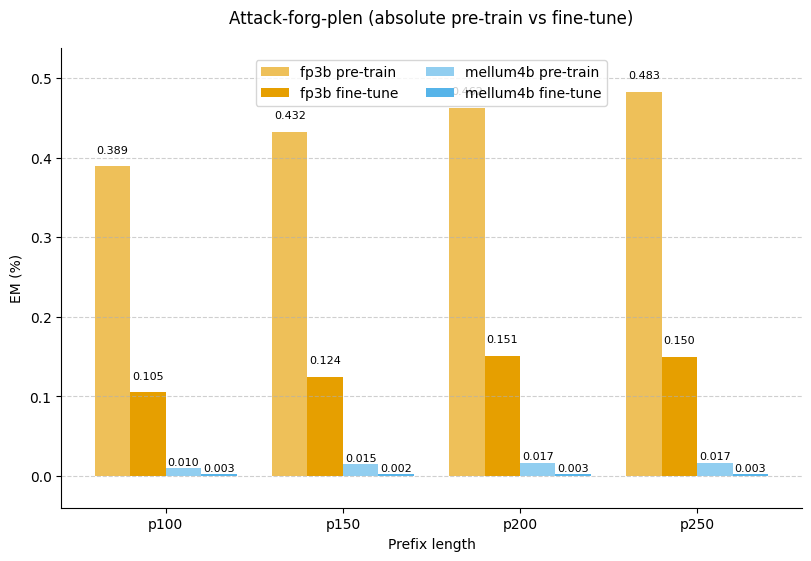

In [42]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
x = np.arange(len(forg_plen_compare.index))
w = 0.2

b_fp0 = ax.bar(x - 1.5 * w, forg_plen_compare["fp3b_pretrain"], w, label="fp3b pre-train", color=FP3B_COLOR, alpha=0.65)
b_fp3 = ax.bar(x - 0.5 * w, forg_plen_compare["fp3b_finetune"], w, label="fp3b fine-tune", color=FP3B_COLOR)
b_me0 = ax.bar(x + 0.5 * w, forg_plen_compare["mellum4b_pretrain"], w, label="mellum4b pre-train", color=ME4B_COLOR, alpha=0.65)
b_me3 = ax.bar(x + 1.5 * w, forg_plen_compare["mellum4b_finetune"], w, label="mellum4b fine-tune", color=ME4B_COLOR)

lb_fp, ub_fp = add_dual_bar_labels(ax, b_fp0, b_fp3)
lb_me, ub_me = add_dual_bar_labels(ax, b_me0, b_me3)

all_vals = np.concatenate(
    [
        forg_plen_compare["fp3b_pretrain"].values,
        forg_plen_compare["fp3b_finetune"].values,
        forg_plen_compare["mellum4b_pretrain"].values,
        forg_plen_compare["mellum4b_finetune"].values,
    ]
)
set_smart_ylim(
    ax,
    all_vals,
    label_bounds=(min(lb_fp, lb_me), max(ub_fp, ub_me)),
)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_xlabel("Prefix length")
ax.set_ylabel("EM (%)")
ax.set_xticks(x)
ax.set_xticklabels(forg_plen_compare.index)
ax.set_title("Attack-forg-plen (absolute pre-train vs fine-tune)", pad=18)
ax.legend(frameon=True, loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()
fig.savefig("./bar-compare_forg_plen_fp3b_vs_mellum4b.pdf", format="pdf", bbox_inches="tight")
